In [1]:
pip install uv


Note: you may need to restart the kernel to use updated packages.


In [2]:
uv pip install ISLP

Note: you may need to restart the kernel to use updated packages.


Using Python 3.13.9 environment at: C:\Users\Fatima zahra\anaconda3
Checked 1 package in 8.00s


Exercises

1. For each of parts (a) through (d), indicate whether we would generally expect the performance of a flexible statistical learning method to be better or worse than an inflexible method. Justify your answer.


$a) Large n, small p : flexible performs better.$

With a very large sample, a flexible method has enough data to estimate its extra parameters reliably, so the variance penalty is small. Meanwhile it can capture structure that an inflexible method would miss, reducing bias. Net effect: better fit.

$b) Large p, small n: flexible performs worse.$

With few observations relative to predictors, a flexible method has too much freedom and will fit noise rather than signal. Variance explodes and overfitting is likely, so the more rigid method generalizes better.

$c) Highly non-linear relationship: flexible performs better.$

An inflexible method (e.g. linear regression) imposes a functional form the true relationship doesn't have, leaving high bias that no amount of data can fix. A flexible method can approximate the non-linear shape, so the reduction in bias outweighs the added variance.

$d) Very high σ² = Var(ε) : flexible performs worse.$

σ² is irreducible noise in the data, not signal. A flexible method will bend to accommodate that noise, inflating variance and overfitting; an inflexible method smooths over it. So the rigid approach is safer here.

2. Explain whether each scenario is a classification or regression problem, and indicate whether we are most interested in inference or prediction. Finally, provide n and p.


$CEO salary$

Regression problem  the response (CEO salary) is a quantitative variable. We are most interested in inference, since the goal is to understand which factors affect salary rather than to predict any particular firm's salary. n = 500 (top 500 US firms), p = 3 (profit, number of employees, industry).

$New product success$

Classification problem,the response is categorical (success or failure). We are most interested in prediction, since the aim is to determine whether the new product will succeed, not to explain the underlying drivers. n = 20 (previously launched similar products), p = 13 (price, marketing budget, competition price, plus ten other variables).

$USD/Euro exchange rate$

Regression problem, the response (% change in the USD/Euro rate) is quantitative. We are most interested in prediction, since the goal is forecasting the rate change rather than explaining the mechanism. n = 52 (weekly observations across 2012), p = 3 (% change in the US, British, and German markets).

3. We now revisit the bias-variance decomposition.
   
(a) Provide a sketch of typical (squared) bias, variance, training error, test error, and Bayes (or irreducible) error curves, on a single plot, as we go from less flexible statistical learning methods
towards more flexible approaches. The x-axis should represent
the amount of flexibility in the method, and the y-axis should
represent the values for each curve. There should be five curves.
Make sure to label each one.

(b) Explain why each of the five curves has the shape displayed in
part (a).

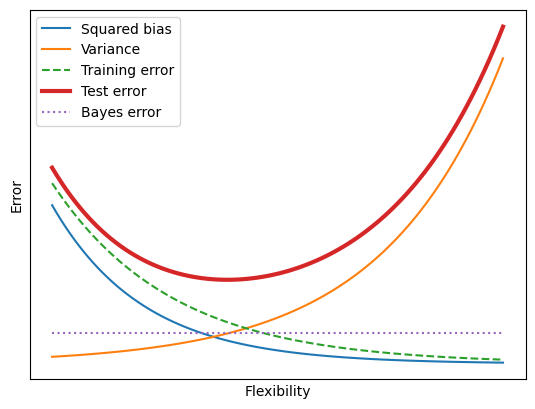

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(1, 10, 100)

bias2 = 9 * np.exp(-0.55 * x)
variance = 0.15 * np.exp(0.42 * x)
irreducible = np.ones_like(x)
test = bias2 + variance + irreducible
train = 9 * np.exp(-0.42 * x)

plt.plot(x, bias2, label="Squared bias")
plt.plot(x, variance, label="Variance")
plt.plot(x, train, "--", label="Training error")
plt.plot(x, test, lw=3, label="Test error")
plt.plot(x, irreducible, ":", label="Bayes error")

plt.xlabel("Flexibility")
plt.ylabel("Error")
plt.xticks([]); plt.yticks([])
plt.legend()
plt.show()

4. You will now think of some real-life applications for statistical learning.
   
(a) Describe three real-life applications in which classification might
be useful. Describe the response, as well as the predictors. Is the
goal of each application inference or prediction? Explain your
answer.

(b) Describe three real-life applications in which regression might
be useful. Describe the response, as well as the predictors. Is the
goal of each application inference or prediction? Explain your
answer.

(c) Describe three real-life applications in which cluster analysis
might be useful.

$(a) Classification$

**1. Product price tier.** Response: price category (cheap / moderate / expensive) categorical, so classification. Predictors: material, weight, brand, warranty length, and durability rating. The goal is inference, since we want to understand which product attributes drive a higher price tier rather than to price any one new item.

**2. Car version identification.** Response: which version a car belongs to (version 1, 2, or 3) categorical, so classification. Predictors: horsepower, battery capacity, weight, gear ratio, top speed, and other design specifications. The goal is prediction, since we want to assign a version label to an unidentified car rather than understand what distinguishes the versions.

**3. Apartment size class.** Response: size category (small = 1 bedroom, medium = 2–3 bedrooms, large = 4+ bedrooms) categorical, so classification. Predictors: neighbourhood, city, listing price, building age, and whether the unit has a balcony or parking. The goal is prediction, since we want to assign a size class to a new listing rather than explain what drives apartment size.

$(b) Regression$

**1. Car top speed.** Response: top speed in km/h quantitative, so regression. Predictors: gear ratio, horsepower, battery capacity, weight, engine displacement, and other design specifications. The goal is prediction, since we want an estimated speed for a new model from its specs rather than an explanation of which factors drive speed.

**2. Litter size in cats.** Response: number of kittens born quantitative, so regression. Predictors: the mother's age, weight, body condition, breed, and number of previous litters. n = 13 cats observed. The goal is prediction, since we want to estimate litter size for a new pregnant cat. Note that with only 13 observations and several predictors, an inflexible method would be preferable here.

**3. Viewer age for a streaming title.** Response: average viewer age of a title quantitative, so regression. Predictors: genre, release year, runtime, content rating, and country of production. The goal is inference, since we want to understand which title characteristics attract older or younger audiences rather than predict the figure for any one title.

$(c) Cluster analysis$

**1. Hospital typologies.** Using CMS quality data  readmission rates, mortality, patient safety indicators, infection rates, and patient experience scores hospitals can be clustered into performance profiles. There is no response variable: no hospital arrives pre-labelled with a type. The value is discovering that institutions with different official categories behave similarly in practice, which a supervised method could not reveal because those labels do not exist to train on.

**2. Grouping a key collection.** Keys can be clustered using length, width, thickness, tooth pattern, head shape, and weight. No key comes labelled with a group, so the algorithm returns unlabelled clusters that are interpreted afterward  one group turning out to be door keys, another padlock keys, another vehicle keys. The same approach applies to any large collection of unlabelled physical artifacts.

**3. City typologies.** Cities can be clustered using population size, density, cost of living, green space per capita, average commute time, cultural venues per capita, and median age. There is no response variable no city is pre-labelled with a type. The goal is to discover which cities resemble each other in how they actually function, groupings that may cut across country and region boundaries entirely.

5. What are the advantages and disadvantages of a very flexible (versus
a less flexible) approach for regression or classification? Under what
circumstances might a more flexible approach be preferred to a less
flexible approach? When might a less flexible approach be preferred

$Advantages of a very flexible approach$

A flexible method can fit a much wider range of possible shapes for $f$, since it makes few assumptions about its functional form. 

$Disadvantages of a very flexible approach$

Flexibility raises variance and the risk of overfitting, as the model may fit noise rather than signal. It also requires far more observations to estimate reliably, since it has many more parameters.

$When a more flexible approach is preferred$

A flexible approach is preferred when the goal is prediction rather than explanation, since only the accuracy of $\hat{y}$ matters. It is also preferred when the true relationship is highly non-linear, because a rigid method would carry high bias that no amount of data could remove, and when $n$ is large relative to $p$, since abundant data keeps the added variance under control.

$When a less flexible approach is preferred$

A less flexible approach is preferred when the goal is inference and we want to understand the relationship between X and Y, since simpler models are interpretable. 

6. Describe the differences between a parametric and a non-parametric
statistical learning approach. What are the advantages of a parametric approach to regression or classification (as opposed to a nonparametric approach)? What are its disadvantages?

$Parametric  approach$

A parametric approach reduces the problem of estimating $f$ to estimating a set of parameters. It proceeds in two steps. First, assume a functional form for $f$, Second, use the training data to fit that model by estimating its parameters. Instead of estimating an entirely arbitrary function, we only need to estimate a fixed, small number of coefficients.

$Non-parametric  approach$

A non-parametric approach makes no assumption about the functional form of $f$. There is no fixed parameter set to estimate. Instead the method seeks an estimate that gets as close to the data points as possible while remaining smooth, allowing the data itself to determine the shape of $f$.

$Advantages  of  the  parametric  approach$

Estimating a fixed set of parameters is far simpler than estimating an arbitrary function, so the approach requires many fewer observations to produce a usable model. The resulting fits are also generally more interpretable, since each coefficient describes how a predictor relates to the response.

$Disadvantages  of  the  parametric  approach$

The chosen model may not match the true form of $f$. If the assumed form is far from reality, the estimate will be poor regardless of how much data is collected. 



$Advantages  of  the  non-parametric  approach$

By avoiding any assumption about the functional form of $f$, this approach has the potential to accurately fit a much wider range of possible shapes. It avoids the danger of a badly chosen functional form, so it can succeed in cases where a parametric method carries irreducible bias no matter how much data is available.

$Disadvantages of the non-parametric approach$

Because the problem of estimating $f$ is not reduced to a small number of parameters, a very large number of observations is required to obtain an accurate estimate. The added flexibility also raises variance and the risk of overfitting, since the method may fit noise rather than signal. The resulting fits are typically harder to interpret than parametric ones.

Suppose we wish to use this data set to make a prediction for Y when
X1 = X2 = X3 =0 using K-nearest neighbors.
    
(a) Compute the Euclidean distance between each observation and
the test point, X1 = X2 = X3 =0.
(b) What is our prediction with K =1? Why?
(c) What is our prediction with K =3? Why?
(d) If the Bayes decision boundary in this problem is highly nonlinear, then would we expect the best value for K to be large or
small? Why?

**$$\text{(a) Euclidean distances to the test point } (0,0,0)$$**

Using $d = \sqrt{X_1^2 + X_2^2 + X_3^2}$:

| Obs | $X_1, X_2, X_3$ | Computation | $d$ | $Y$ |
|---|---|---|---|---|
| 1 | 0, 3, 0 | $\sqrt{0+9+0} = \sqrt{9}$ | 3.00 | Red |
| 2 | 2, 0, 0 | $\sqrt{4+0+0} = \sqrt{4}$ | 2.00 | Red |
| 3 | 0, 1, 3 | $\sqrt{0+1+9} = \sqrt{10}$ | 3.16 | Red |
| 4 | 0, 1, 2 | $\sqrt{0+1+4} = \sqrt{5}$ | 2.24 | Green |
| 5 | −1, 0, 1 | $\sqrt{1+0+1} = \sqrt{2}$ | 1.41 | Green |
| 6 | 1, 1, 1 | $\sqrt{1+1+1} = \sqrt{3}$ | 1.73 | Red |

Ranked from nearest to farthest: obs 5, 6, 2, 4, 1, 3.

**$$\text{(b) Prediction with } K = 1$$**

The prediction is **Green**. With $K = 1$ we use only the single nearest observation, which is obs 5 at distance 1.41, and its response is Green. No vote takes place, one neighbour determines the prediction entirely.

**$$\text{(c) Prediction with } K = 3$$**

The prediction is **Red**. The three nearest observations are obs 5 (1.41, Green), obs 6 (1.73, Red) and obs 2 (2.00, Red). KNN estimates $P(Y = \text{Red} \mid X = x_0) = 2/3$ and $P(Y = \text{Green} \mid X = x_0) = 1/3$, and classifies to the larger probability. The prediction differs from part (b), showing how sensitive KNN is to the choice of $K$.

**$$\text{(d) Best value of } K \text{ for a highly non-linear boundary}$$**

We would expect the best $K$ to be **small**. In KNN, $K$ controls flexibility inversely: a small $K$ gives a highly flexible method whose decision boundary can change sharply from one region to the next, while a large $K$ averages over many neighbours and produces a smooth, nearly linear boundary. If the true Bayes decision boundary is highly non-linear, only a flexible fit can trace its shape. A large $K$ would impose excessive smoothing and carry high bias that no amount of data could remove.

In [4]:
import pandas as pd 

college = pd.read_csv("../Practice/ALL+CSV+FILES+-+2nd+Edition+-+corrected/ALL CSV FILES - 2nd Edition/College.csv")

college.head()


,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [5]:
college= college.rename({'Unnamed: 0': 'College'},axis=1)
college = college.set_index('College')
college.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
College,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [6]:
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


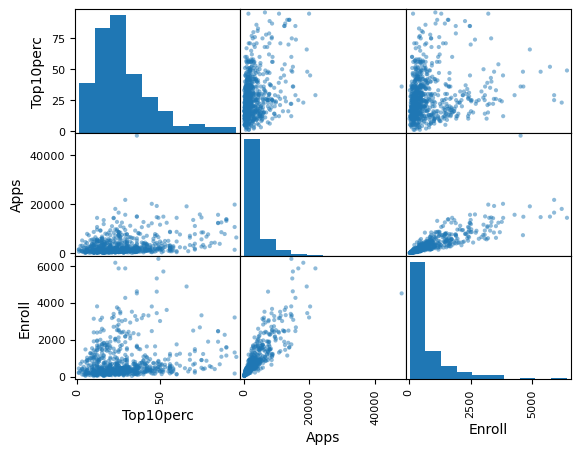

In [7]:
import matplotlib.pyplot as plt
pd.plotting.scatter_matrix(college[['Top10perc', 'Apps', 'Enroll']])
plt.show()


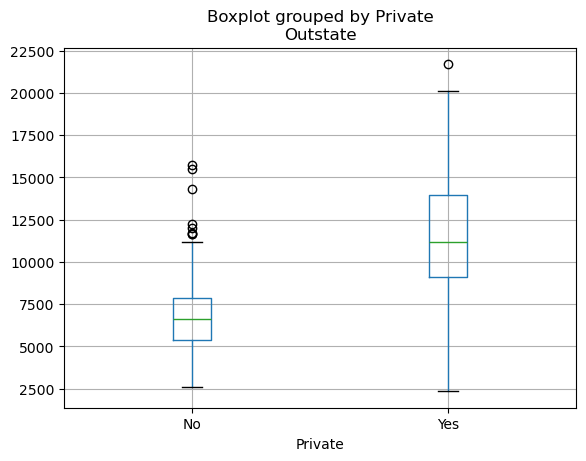

In [8]:
pd.plotting.boxplot(data = college, column='Outstate', by='Private')
plt.show()

In [9]:
college["Elite"] = pd.cut(college["Top10perc"], [0, 50, 100], labels=["No", "Yes"])
college["Elite"].value_counts()


Elite
No     699
Yes     78
Name: count, dtype: int64

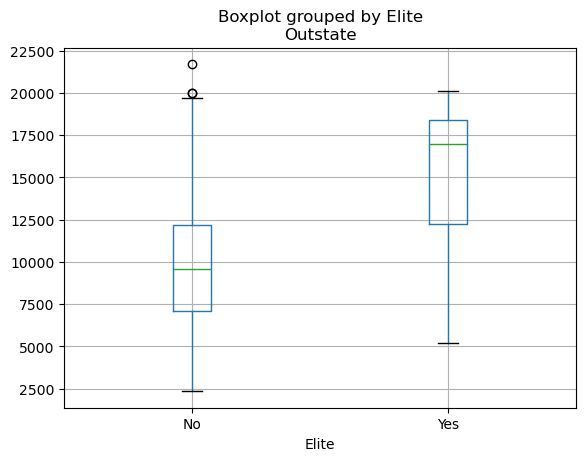

In [10]:

pd.plotting.boxplot(data = college, column='Outstate', by='Elite')
plt.show()

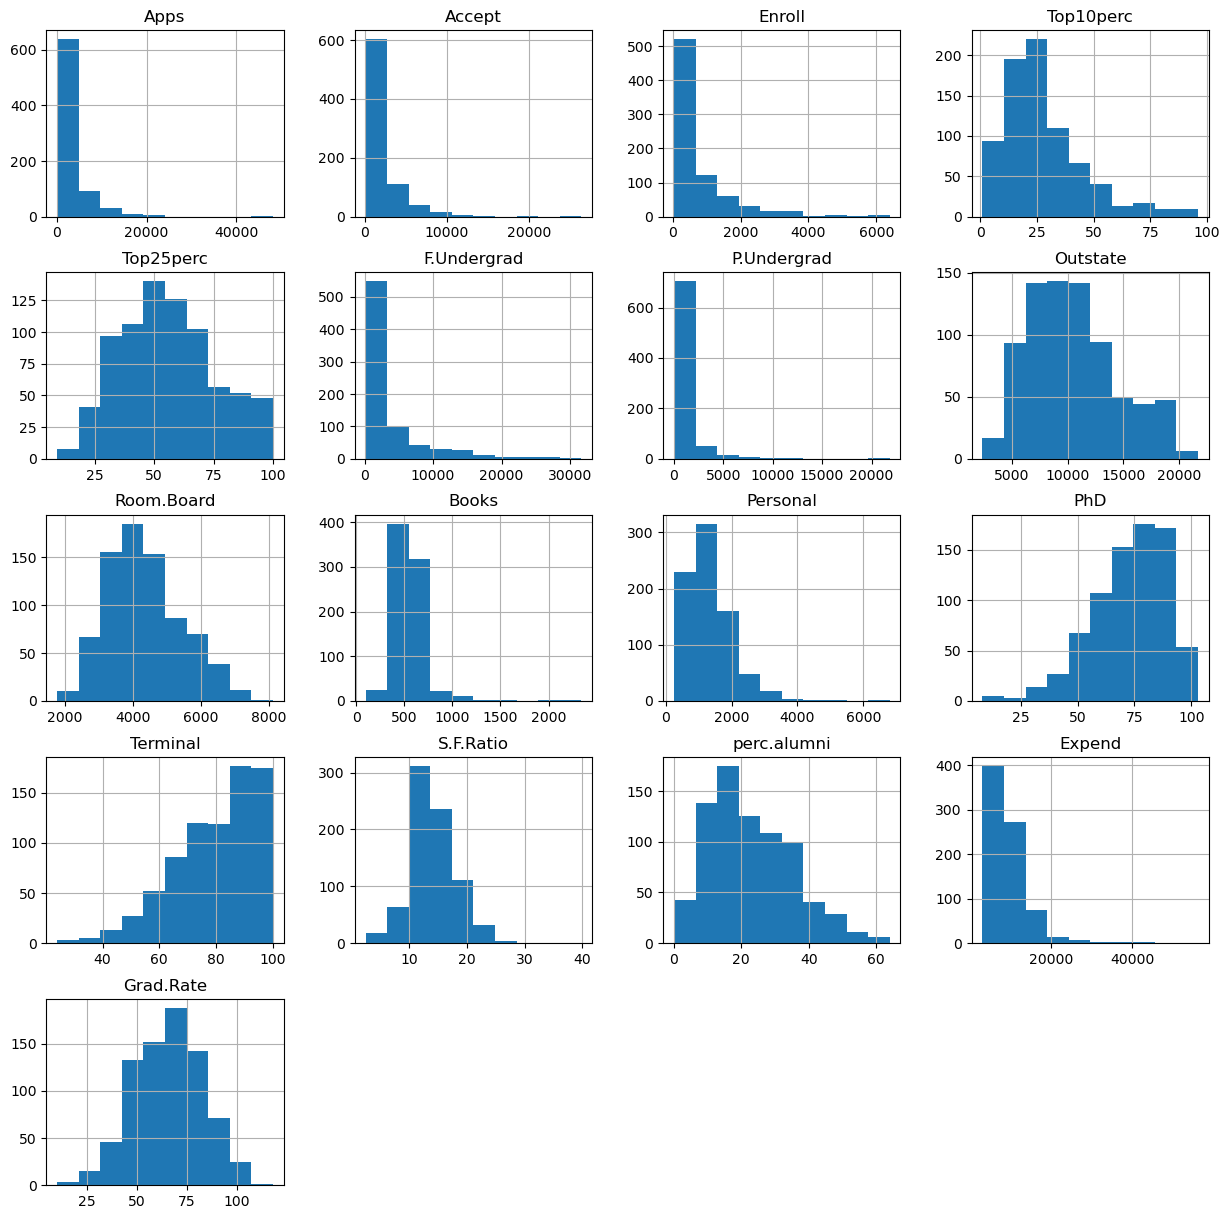

In [11]:
college.hist(figsize=(15,15));

In [12]:
college["Accept.Rate"] = college["Accept"] / college["Apps"]
college["Yield"] = college["Enroll"] / college["Accept"]
college.groupby("Elite")[["Accept.Rate", "Yield"]].mean()

C:\Users\Fatima zahra\AppData\Local\Temp\ipykernel_7992\3390679573.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  college.groupby("Elite")[["Accept.Rate", "Yield"]].mean()


,Accept.Rate,Yield
Elite,,
No,0.769638,0.415868
Yes,0.543409,0.377487


In [13]:
college[college["Grad.Rate"] > 100]
college.corr(numeric_only=True)["Grad.Rate"].sort_values()

S.F.Ratio     -0.306710
Yield         -0.293049
Accept.Rate   -0.286972
Personal      -0.269344
P.Undergrad   -0.257001
F.Undergrad   -0.078773
Enroll        -0.022341
Books          0.001061
Accept         0.067313
Apps           0.146755
Terminal       0.289527
PhD            0.305038
Expend         0.390343
Room.Board     0.424942
Top25perc      0.477281
perc.alumni    0.490898
Top10perc      0.494989
Outstate       0.571290
Grad.Rate      1.000000
Name: Grad.Rate, dtype: float64

<Axes: xlabel='Enroll', ylabel='Grad.Rate'>

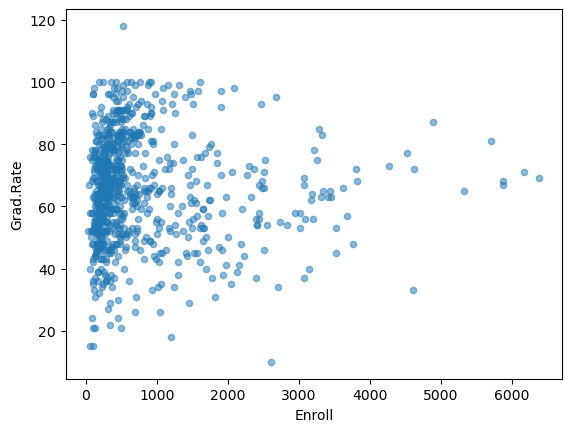

In [14]:
college.plot.scatter(x="Enroll", y="Grad.Rate", alpha=0.5)

Enrollment shows no clear relationship with graduation rate. The points form a broad horizontal cloud rather than any trend, indicating that institution size does little to explain graduation outcomes on its own. The distribution of enrollment is heavily right-skewed, with most colleges enrolling fewer than 1,000 new students and a long tail extending past 6,000. Variability in graduation rate is widest among the smallest institutions, spanning roughly 10% to 100%, and narrows as enrollment increaseslarger institutions cluster in the 60–80% range.

In [15]:

auto = pd.read_csv("../Practice/ALL+CSV+FILES+-+2nd+Edition+-+corrected/ALL CSV FILES - 2nd Edition/Auto.csv")
auto = auto.dropna()
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [16]:
auto.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
year              int64
origin            int64
name             object
dtype: object

name and horse power are categorical , all the remaining are numerical

In [17]:
import numpy as np

In [18]:

print(np.min(auto['mpg'], axis=0))
print(np.max(auto['mpg'], axis=0))  
auto.describe()

9.0
46.6


,mpg,cylinders,displacement,weight,acceleration,year,origin
count,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000
mean,23.515869,5.458438,193.532746,2970.261965,15.555668,75.994962,1.574307
std,7.825804,1.701577,104.379583,847.904119,2.749995,3.690005,0.802549
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.000000,2223.000000,13.800000,73.000000,1.000000
50%,23.000000,4.000000,146.000000,2800.000000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3609.000000,17.100000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


The book means observations 10–85 in 1-based counting, so with pandas' 0-based positions that's positions 9 through 84:

In [19]:
auto_proc = auto.drop(auto.index[9:85])

quant = auto_proc.select_dtypes(include="number").drop(columns=["name"], errors="ignore")
pd.DataFrame({
    "range": quant.max() - quant.min(),
    "min": quant.min(),
    "max": quant.max(),
    "mean": quant.mean(),
    "std": quant.std()
}).round(2)

,range,min,max,mean,std
mpg,35.6,11.0,46.6,24.44,7.91
cylinders,5.0,3.0,8.0,5.37,1.65
displacement,387.0,68.0,455.0,187.05,99.64
weight,3348.0,1649.0,4997.0,2933.96,810.64
acceleration,16.3,8.5,24.8,15.72,2.68
year,12.0,70.0,82.0,77.15,3.11
origin,2.0,1.0,3.0,1.60,0.82


,mpg,cylinders,displacement,weight,acceleration,year,origin
mpg,1.00,-0.78,-0.80,-0.83,0.42,0.58,0.56
cylinders,-0.78,1.00,0.95,0.90,-0.50,-0.35,-0.56
displacement,-0.80,0.95,1.00,0.93,-0.54,-0.37,-0.61
weight,-0.83,0.90,0.93,1.00,-0.42,-0.31,-0.58
acceleration,0.42,-0.50,-0.54,-0.42,1.00,0.28,0.21
year,0.58,-0.35,-0.37,-0.31,0.28,1.00,0.18
origin,0.56,-0.56,-0.61,-0.58,0.21,0.18,1.00


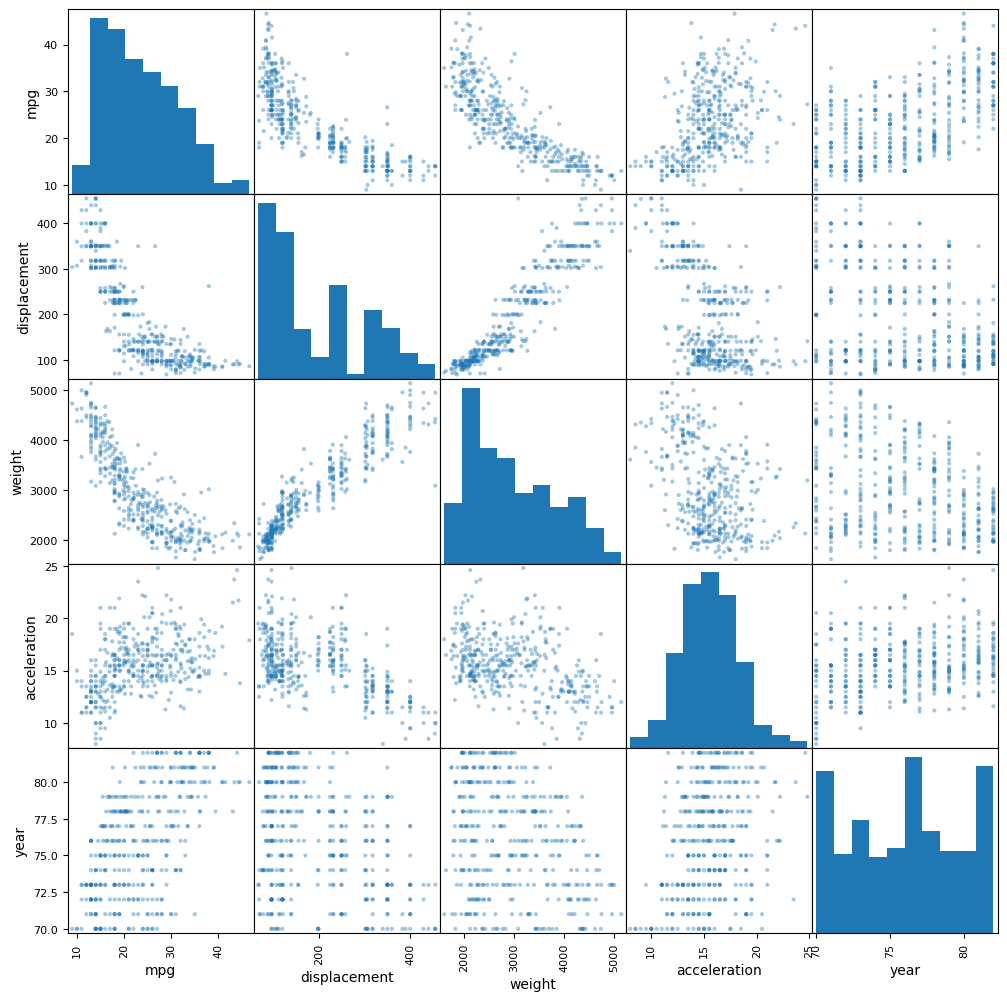

In [20]:
pd.plotting.scatter_matrix(auto[["mpg","displacement","horsepower","weight","acceleration","year"]], figsize=(12,12), alpha=0.4)

auto.corr(numeric_only=True).round(2)

Yes. The scatterplots and correlation matrix indicate that weight, displacement and horsepower all have strong negative associations with mpg (correlations of approximately −0.83, −0.81 and −0.78 respectively), making them clearly useful predictors. Year is positively associated with mpg, reflecting steady efficiency gains across model years, and cylinders and origin also separate mpg levels visibly. Acceleration shows only a weak relationship and would be less useful.

Two caveats follow from the plots. First, the relationships between mpg and weight, displacement and horsepower are visibly non-linear, mpg falls steeply among lighter cars and flattens among heavy ones so a model including transformed terms would fit better than a purely linear one. Second, weight, displacement and horsepower are highly correlated with one another, so they carry largely overlapping information; including all three would not add three predictors' worth of value.

In [21]:

boston = pd.read_csv("../Practice/ALL+CSV+FILES+-+2nd+Edition+-+corrected/ALL CSV FILES - 2nd Edition/Boston.csv")
boston = boston.dropna()
boston.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [22]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  lstat       506 non-null    float64
 13  medv        506 non-null    float64
dtypes: float64(10), int64(4)
memory usage: 55.5 KB


In [23]:
boston = boston.drop(columns=["Unnamed: 0"])

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
crim,1.00,-0.20,0.41,-0.06,0.42,-0.22,0.35,-0.38,0.63,0.58,0.29,0.46,-0.39
zn,-0.20,1.00,-0.53,-0.04,-0.52,0.31,-0.57,0.66,-0.31,-0.31,-0.39,-0.41,0.36
indus,0.41,-0.53,1.00,0.06,0.76,-0.39,0.64,-0.71,0.60,0.72,0.38,0.60,-0.48
chas,-0.06,-0.04,0.06,1.00,0.09,0.09,0.09,-0.10,-0.01,-0.04,-0.12,-0.05,0.18
nox,0.42,-0.52,0.76,0.09,1.00,-0.30,0.73,-0.77,0.61,0.67,0.19,0.59,-0.43
rm,-0.22,0.31,-0.39,0.09,-0.30,1.00,-0.24,0.21,-0.21,-0.29,-0.36,-0.61,0.70
age,0.35,-0.57,0.64,0.09,0.73,-0.24,1.00,-0.75,0.46,0.51,0.26,0.60,-0.38
dis,-0.38,0.66,-0.71,-0.10,-0.77,0.21,-0.75,1.00,-0.49,-0.53,-0.23,-0.50,0.25
rad,0.63,-0.31,0.60,-0.01,0.61,-0.21,0.46,-0.49,1.00,0.91,0.46,0.49,-0.38
tax,0.58,-0.31,0.72,-0.04,0.67,-0.29,0.51,-0.53,0.91,1.00,0.46,0.54,-0.47


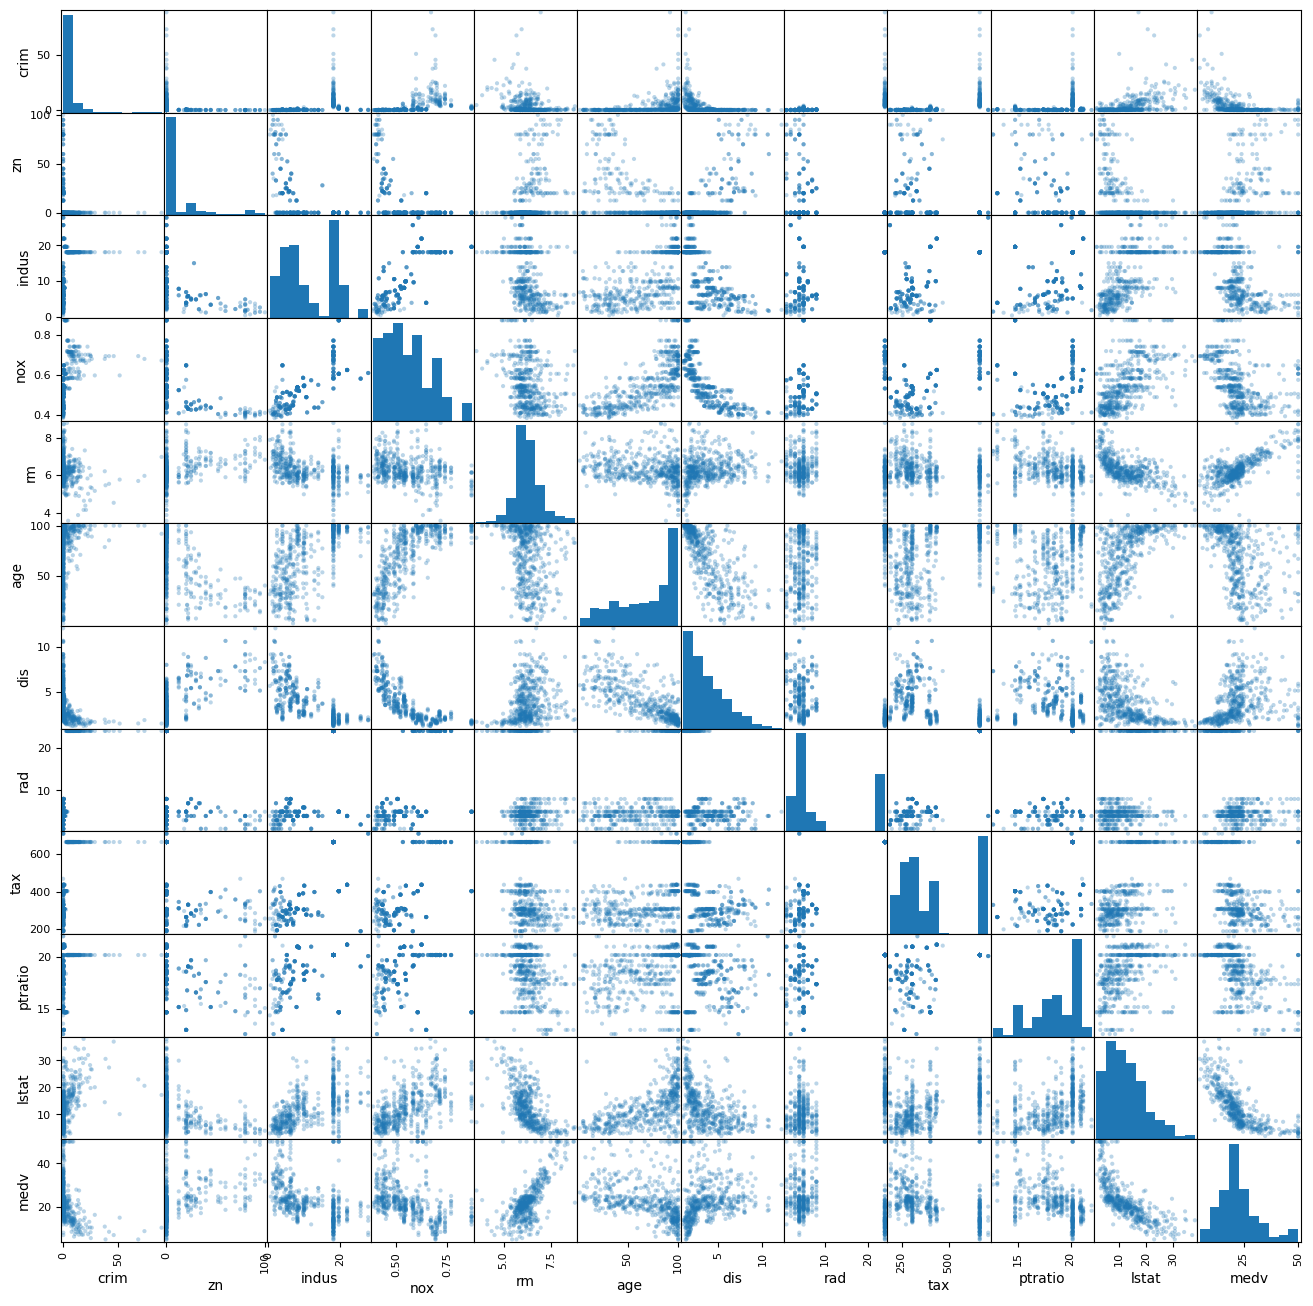

In [24]:
# (c)
cols = ["crim","zn","indus","nox","rm","age","dis","rad","tax","ptratio","lstat","medv"]
pd.plotting.scatter_matrix(boston[cols], figsize=(16,16), alpha=0.3)
boston.corr().round(2)


In [25]:

# (d)
boston.corr()["crim"].sort_values()

# (e)
boston[["crim","tax","ptratio"]].describe()
boston.sort_values("crim", ascending=False).head(10)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
380,88.9762,0.0,18.1,0,0.671,6.968,91.9,1.4165,24,666,20.2,17.21,10.4
418,73.5341,0.0,18.1,0,0.679,5.957,100.0,1.8026,24,666,20.2,20.62,8.8
405,67.9208,0.0,18.1,0,0.693,5.683,100.0,1.4254,24,666,20.2,22.98,5.0
410,51.1358,0.0,18.1,0,0.597,5.757,100.0,1.4130,24,666,20.2,10.11,15.0
414,45.7461,0.0,18.1,0,0.693,4.519,100.0,1.6582,24,666,20.2,36.98,7.0
404,41.5292,0.0,18.1,0,0.693,5.531,85.4,1.6074,24,666,20.2,27.38,8.5
398,38.3518,0.0,18.1,0,0.693,5.453,100.0,1.4896,24,666,20.2,30.59,5.0
427,37.6619,0.0,18.1,0,0.679,6.202,78.7,1.8629,24,666,20.2,14.52,10.9
413,28.6558,0.0,18.1,0,0.597,5.155,100.0,1.5894,24,666,20.2,20.08,16.3
417,25.9406,0.0,18.1,0,0.679,5.304,89.1,1.6475,24,666,20.2,26.64,10.4


In [26]:

# (f) and (g)
(boston["chas"] == 1).sum()
boston["ptratio"].median()


19.05

In [27]:

# (h)
boston[boston["medv"] == boston["medv"].min()]
boston.describe()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


In [28]:

# (i)
(boston["rm"] > 7).sum()
(boston["rm"] > 8).sum()
boston[boston["rm"] > 8].describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,0.718795,13.615385,7.078462,0.153846,0.539238,8.348538,71.538462,3.430192,7.461538,325.076923,16.361538,4.310000,44.200000
std,0.901640,26.298094,5.392767,0.375534,0.092352,0.251261,24.608723,1.883955,5.332532,110.971063,2.410580,1.373566,8.092383
min,0.020090,0.000000,2.680000,0.000000,0.416100,8.034000,8.400000,1.801000,2.000000,224.000000,13.000000,2.470000,21.900000
25%,0.331470,0.000000,3.970000,0.000000,0.504000,8.247000,70.400000,2.288500,5.000000,264.000000,14.700000,3.320000,41.700000
50%,0.520140,0.000000,6.200000,0.000000,0.507000,8.297000,78.300000,2.894400,7.000000,307.000000,17.400000,4.140000,48.300000
75%,0.578340,20.000000,6.200000,0.000000,0.605000,8.398000,86.500000,3.651900,8.000000,307.000000,17.400000,5.120000,50.000000
max,3.474280,95.000000,19.580000,1.000000,0.718000,8.780000,93.900000,8.906700,24.000000,666.000000,20.200000,7.440000,50.000000


13 suburbs average more than eight rooms per dwelling, and 64 average more than seven. The 13 large-home suburbs differ markedly from the dataset as a whole. Their mean crime rate is 0.72 with a maximum of 3.47, well below the overall maximum of about 89, and lstat is very low, indicating high-status neighbourhoods. Median home values are correspondingly high.